Step 1 — Import Libraries for Model 2

In [1]:
# Step 1: Imports for Model 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")


Step 2 – Load Kaggle datasets

In [2]:
# Step 2: Load Kaggle data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


Step 3 — Encode Categorical Variables

In [3]:
# Step 3: Encode categorical features BEFORE splitting

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 3: Encode categorical features BEFORE splitting
cat_cols = train.select_dtypes(include=["object"]).columns

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    
    # Check if the column exists in the test set
    if col in test.columns:
        # FIX: Combine train and test unique values so 'Always' is learned
        combined_categories = pd.concat([train[col], test[col]]).dropna().unique()
        le.fit(combined_categories)
        
        # Safely transform both datasets
        train[col] = le.transform(train[col])
        test[col] = le.transform(test[col])
    else:
        # Handle columns only in train (like your target 'NObeyesdad')
        train[col] = le.fit_transform(train[col])
        
    label_encoders[col] = le


Step 4 — Recreate Features + Split and Target

In [4]:
# # Step 4: Recreate features and target for Model 2

target_col = "NObeyesdad"

X = train.drop(columns=[target_col])
y = train[target_col]
X_test = test.copy()

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X, y, test_size=0.2, random_state=123
)


Step 5 — Create Train/Validation Split

In [5]:
# Step 5: New train/validation split for Model 2
X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X, y, test_size=0.2, random_state=123
)


Step 6 — Fit Non‑Linear Model 2 (Train Gradient Boosting)

In [6]:
# Step 6: Train Gradient Boosting model (non-linear classification)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Switched from Regressor to Classifier
gbc_model = GradientBoostingClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=123
)

# Train the classification model
gbc_model.fit(X_train2, y_train2)

# # Validation predictions + Accuracy
y_valid2_pred = gbc_model.predict(X_valid2)

# Switched metric from RMSLE to Accuracy Score (standard for classification)
accuracy_gbc = accuracy_score(y_valid2, y_valid2_pred)

print("Model 2 - Gradient Boosting Accuracy (validation):", accuracy_gbc)


Model 2 - Gradient Boosting Accuracy (validation): 0.9101637764932563


7. GBR Figures Feature Importance

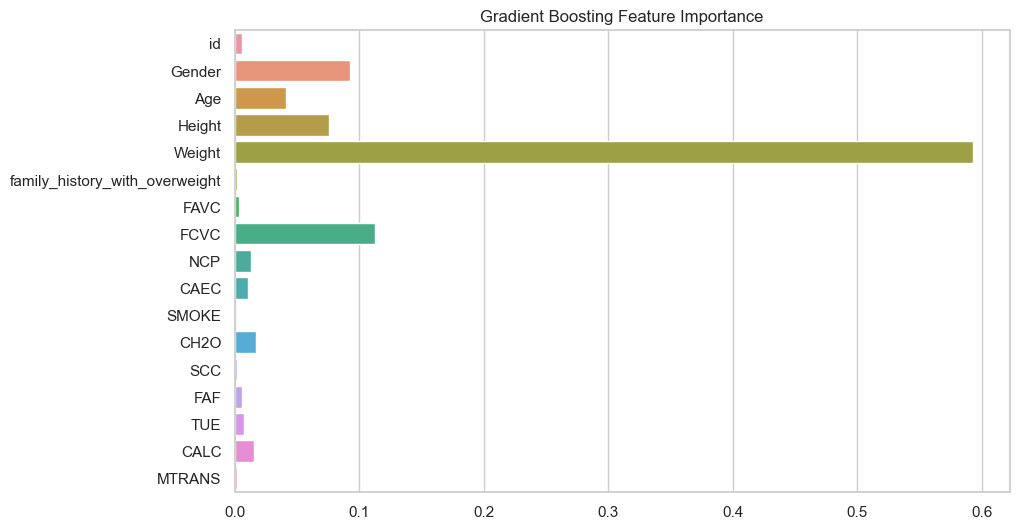

In [7]:
# 7. GBC Figures Feature Importance

importances = gbc_model.feature_importances_
feat_names = X_train2.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feat_names)
plt.title("Gradient Boosting Feature Importance")
plt.savefig("NU/DDS8555/Build_Non-Linear_Models_Part 2/figures/model2_gbr_feature_importance.png")
plt.show()


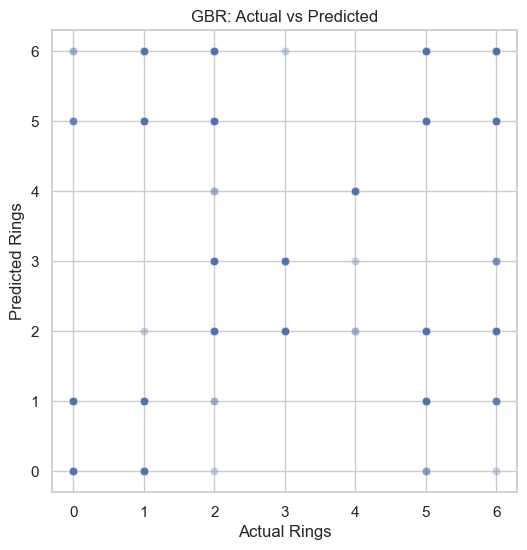

In [8]:
# 8 Actual vs Predicted

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_valid2, y=y_valid2_pred, alpha=0.3)
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("GBR: Actual vs Predicted")
plt.savefig("NU/DDS8555/Build_Non-Linear_Models_Part 2/figures/model2_gbr_actual_vs_pred.png")
plt.show()


C:\Users\sjrey\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


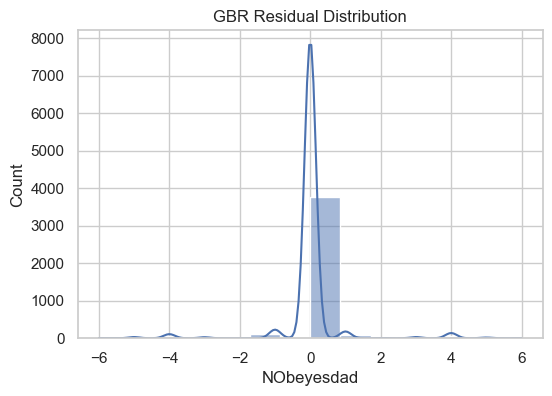

In [9]:
# 9. Residuals

residuals_gbr = y_valid2 - y_valid2_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals_gbr, kde=True)
plt.title("GBR Residual Distribution")
plt.savefig("NU/DDS8555/Build_Non-Linear_Models_Part 2/figures/model2_gbr_residuals.png")
plt.show()


Step 10 — Retrain the Chosen Model on Full Training Data

In [10]:
# 10. Retrain Gradient Boosting on full data

gbr_model_full = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=123
)

gbr_model_full.fit(X, y)

# Predict on Kaggle test set
test_pred_gbr = gbr_model_full.predict(X_test)


C:\Users\sjrey\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


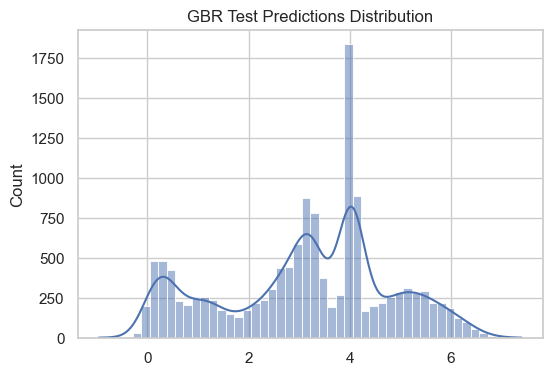

In [11]:
#11. GBR Prediction Distribution

plt.figure(figsize=(6, 4))
sns.histplot(test_pred_gbr, kde=True)
plt.title("GBR Test Predictions Distribution")
plt.savefig("NU/DDS8555/Build_Non-Linear_Models_Part 2/figures/model2_gbr_prediction_distribution.png")
plt.show()


Step 8 — Build Second Submission File

In [12]:
# Step 8: Create second submission DataFrame
submission_gbr = sample_submission.copy()
submission_gbr["Rings"] = test_pred_gbr

# Save CSV for Kaggle
submission_gbr.to_csv("NU/DDS8555/Build_Non-Linear_Models_Part 2/submission/submission_model2_gradient_boosting.csv", index=False)

submission_gbr.head()


,id,NObeyesdad,Rings
0,20758,Normal_Weight,2.987163
1,20759,Normal_Weight,5.175897
2,20760,Normal_Weight,4.009063
3,20761,Normal_Weight,2.901748
4,20762,Normal_Weight,4.026052
